In [1]:
## In this example, we will study output data frame from pandora.py configuration
#### 1. Opening each data frame and check structure
#### 2. Collect POT and scale factor to the target POT
#### 3. Merge evtdf and mcnudf for further study
#### 4. Draw some plots for each slice and for each pfp

import os
import sys
import lmfit
import numpy as np
import math
import uproot as uproot
import pickle
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import ticker
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
from matplotlib import gridspec


# Absolute path to cafpyana directory
print('Importing cafpyana utils...')
cafpyana_root = "/home/lpelegri/cafpyana"
# Add CAFpyana to the Python search path -- this will allow you to import cafpyana modules
sys.path.insert(0, cafpyana_root)

from analysis_village.unfolding.wienersvd import *
from analysis_village.unfolding.unfolding_inputs import *

from analysis_village.cc1pi.HelperFunctions import HelperFunctions
from analysis_village.cc1pi.Constants import CTE as CTE
from analysis_village.cc1pi.CutMasks.MaskUtils import *
from analysis_village.cc1pi.CutMasks.CutMasks import *
from analysis_village.cc1pi.DataFrameUtils import DFCleaning
from analysis_village.cc1pi.GraphUtils.GraphsUtils import *
from analysis_village.cc1pi.DataFrameUtils.DFLoading import *
from analysis_village.cc1pi.Optimize import OptimizationUtils
from analysis_village.cc1pi.Optimize import ConfusionMatricesUtils
from analysis_village.cc1pi.BDTs import BDTTrainingUtils

# import this repo's classes
import pyanalib.pandas_helpers as ph
import pyanalib.split_df_helpers as splh
import pyanalib.stat_helpers as sh

np.seterr(divide='ignore', invalid='ignore', over='ignore')

import uproot
import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, FancyBboxPatch
from matplotlib.colors import to_rgba
from pathlib import Path

Importing cafpyana utils...
Importing cafpyana utils...


In [2]:
use_range_momentum = False
plot_inter          = "Inelastic"          # "Inelastic", "Stopping", "All", "Range"
use_num_hits        = False
hits_to_plot        = "used"         # "used" or "removed"
#filename            = "211_MC_selection_all"
filename            = "211_MC_selection_result"

# Only used when use_num_hits = True. Edit to match the bins you want;
# the last edge behaves like the ROOT loop's "i_hb == n_hit_bins - 1"
# case, i.e. it becomes an inclusive ">=" upper-open bin.
hit_bins = [0,50,100,200,300,500,750]

input_dir  = Path("/exp/sbnd/data/users/lpelegri/TLE_processed_files")
output_dir = Path("/exp/sbnd/data/users/lpelegri/TLEGraphs/MethodComparisons")

In [3]:
file_path = input_dir / f"{filename}.root"
tree = uproot.open(file_path)["tree"]

scalar_fields = [
    "true_P", "range_P", "length", "purity", "completeness", "PDG",
    "end_process_string", "out_best_plane", "used_plane",
    "num_used_hits", "num_initial_hits", "num_removed_hits",
]
vector_fields = ["method_vector", "P_track_extension_method", "exit_code"]

arrays = tree.arrays(scalar_fields + vector_fields, library="ak")
n_events = len(arrays)
print(f"Entries: {n_events}")

# Sanity check: the three vector branches must be aligned per-event
# (index i_p means the same thing in each), same as the C++ loop assumes.
assert ak.all(ak.num(arrays["method_vector"]) == ak.num(arrays["exit_code"]))
assert ak.all(ak.num(arrays["method_vector"]) == ak.num(arrays["P_track_extension_method"]))

Entries: 25820


In [4]:
print(file_path)

/exp/sbnd/data/users/lpelegri/TLE_processed_files/211_MC_selection_result.root


In [5]:
def to_flat_numpy(ak_array):
    # Convert any awkward array (numeric or string) to a flat numpy array.
    try:
        return ak.to_numpy(ak_array)
    except Exception:
        return np.array(ak.to_list(ak_array), dtype=object)

counts = ak.to_numpy(ak.num(arrays["method_vector"], axis=1))

data = {"entry": np.repeat(np.arange(n_events), counts)}
for f in scalar_fields:
    data[f] = np.repeat(to_flat_numpy(arrays[f]), counts)
for f in vector_fields:
    data[f] = to_flat_numpy(ak.flatten(arrays[f], axis=1))

df = pd.DataFrame(data).rename(columns={
    "PDG": "pdg",
    "method_vector": "method",
    "P_track_extension_method": "reco_P_method",
})

print(f"Rows after flattening (event x method): {len(df)}")
df.head()

Rows after flattening (event x method): 129100


,entry,true_P,range_P,length,purity,completeness,pdg,end_process_string,out_best_plane,used_plane,num_used_hits,num_initial_hits,num_removed_hits,method,reco_P_method,exit_code
0,0,0.170863,0.163561,17.476734,0.932724,0.892361,211,Decay,1,1,50,50,0,range,0.160971,0
1,0,0.170863,0.163561,17.476734,0.932724,0.892361,211,Decay,1,1,50,50,0,original,0.168166,0
2,0,0.170863,0.163561,17.476734,0.932724,0.892361,211,Decay,1,1,50,50,0,normalize_clean_dEdx_include_small,0.236905,0
3,0,0.170863,0.163561,17.476734,0.932724,0.892361,211,Decay,1,1,50,50,0,convolution_normalize_clean_dEdx_include_small_og,0.160971,0
4,0,0.170863,0.163561,17.476734,0.932724,0.892361,211,Decay,1,1,50,50,0,convolution_normalize_clean_dEdx_include_small...,0.160971,0


In [6]:
print(df[df.end_process_string != "Decay"].end_process_string)

25                       hIoni
26                       hIoni
27                       hIoni
28                       hIoni
29                       hIoni
                  ...         
129095    muMinusCaptureAtRest
129096    muMinusCaptureAtRest
129097    muMinusCaptureAtRest
129098    muMinusCaptureAtRest
129099    muMinusCaptureAtRest
Name: end_process_string, Length: 34945, dtype: object


In [7]:

if "211" in filename:
    df = df[df["pdg"].abs() == 211].copy()
    df = df[df["exit_code"] == 0].copy()

    df["p_type"] = np.where(
        df["end_process_string"].isin(["pipInelastic", "pimInelastic"]),
        "inelastic pion",
        "stopping pion",
    )
    
elif "13" in filename:
    df = df[df["pdg"].abs() == 13].copy()
    df = df[df["exit_code"] == 0].copy()
    df["p_type"] = "muon"


df["base_P"] = df["range_P"] if use_range_momentum else df["true_P"]
df["residual"] = (df["reco_P_method"] - df["base_P"]) / df["base_P"]
df["hits_col"] = df["num_removed_hits"] if hits_to_plot == "removed" else df["num_used_hits"]

df = df.reset_index(drop=True)
print(f"Rows after pdg/exit_code selection: {len(df)}")
df["method"].value_counts()

Rows after pdg/exit_code selection: 103766


method
range                                                     20757
normalize_clean_dEdx_include_small                        20754
convolution_normalize_clean_dEdx_include_small_og         20754
convolution_normalize_clean_dEdx_include_small_shifted    20754
original                                                  20747
Name: count, dtype: int64

In [26]:
print(df[df.p_type == "stopping pion"].p_type)

0         stopping pion
1         stopping pion
2         stopping pion
3         stopping pion
4         stopping pion
              ...      
103761    stopping pion
103762    stopping pion
103763    stopping pion
103764    stopping pion
103765    stopping pion
Name: p_type, Length: 102416, dtype: object


In [8]:
RANGE_COL = ("slc", "measure_var", "range_p_pi", "", "", "")

range_df = (
    df.loc[df["method"] == "range", ["entry", "reco_P_method"]]
      .rename(columns={"reco_P_method": "range_reco_P"})
)
df = df.merge(range_df, on="entry", how="left")
df[RANGE_COL] = df["range_reco_P"]
df = df.reset_index(drop=True)

In [9]:
class PlotConfig:

    def __init__(
        self,
        truth_column="base_P",
        data_column="reco_P_method",
        plot_column="p_type",
        title=r"$P_{\pi}$",
        unit="[GeV/c]",
        ylabel="Candidate Pions [A.U.]",
        bins=None,
    ):
        self.truth_column = truth_column
        self.data_column = data_column
        self.plot_column = plot_column
        self.title = title
        self.unit = unit
        self.ylabel = ylabel
        self.bins = (
            np.linspace(0.13, 1, 26) if bins is None else np.asarray(bins)
        )



In [10]:
def plot_1d_res(
    mc_df,
    config,
    title=None,
    weight_column=None,
    use_percent_bias=False,
    use_range_momentum=False,
    extra_mask=None,
    data_tot_pot=None,
    plot_inter="All",  # "All", "Stopping", "Inelastic", "Range", "Muon"
):
    # --- 1. Pre-processing ---
    slice_levels = ["__ntuple", "entry", "rec.slc..index"]
    if getattr(config, "first_per_slice", False):
        mc_df = mc_df.groupby(level=slice_levels, sort=False).first()

    if extra_mask is None:
        extra_mask = np.ones(len(mc_df), dtype=bool)

    df_plot = mc_df.loc[extra_mask].copy()

    # Handle weights
    if weight_column is not None and weight_column in df_plot.columns:
        df_plot["plot_w"] = df_plot[weight_column].values
    else:
        df_plot["plot_w"] = np.ones(len(df_plot))

    truth = df_plot[config.truth_column].values
    reco_tle = df_plot[config.data_column].values
    range_col = "range_P"
    reco_range = (
        df_plot[range_col].values if range_col in df_plot.columns else None
    )

    def residual(reco, truth):
        return (reco - truth) / truth if use_percent_bias else (reco - truth)

    x_tle = residual(reco_tle, truth)
    x_range = residual(reco_range, truth) if reco_range is not None else None

    range_filter = (x_tle > -1.5) & (x_tle < 1.5)
    df_plot = df_plot.loc[range_filter].copy()
    df_plot["x_tle"] = x_tle[range_filter]
    if x_range is not None:
        df_plot["x_range"] = x_range[range_filter]

    # --- Masks ---
    p_type = df_plot[config.plot_column]
    stopping_mask = p_type == "stopping pion"
    inelastic_mask = p_type == "inelastic pion"
    muon_mask = p_type.isin(["muon", "stopping muon"])

    bins = np.linspace(-1, 1, 36)

    # --- Colors ---
    COL_INEL = "#009E73"  # Bluish Green
    COL_STOP = "#D55E00"  # Vermilion
    COL_RANGE = "#6C6C6C"  # Mid Gray
    COL_MUON = "#0072B2"  # Blue

    # --- plot_inter gating ---
    include_stop = plot_inter in ("All", "Stopping", "Range")
    include_inel = plot_inter in ("All", "Inelastic", "Range")
    include_range = (plot_inter == "Range") and ("x_range" in df_plot.columns)
    include_muon = plot_inter == "Muon"

    # --- 2. Area-normalize weights per histogram ---
    w = df_plot["plot_w"].values

    def norm_weights(vals, wgts):
        valid = ~np.isnan(vals)
        in_range = valid & (vals >= bins[0]) & (vals <= bins[-1])
        total = wgts[in_range].sum()
        return wgts / total if total > 0 else wgts

    w_stop_tle = (
        norm_weights(
            df_plot.loc[stopping_mask, "x_tle"].values, w[stopping_mask.values]
        )
        if include_stop
        else None
    )
    w_inel_tle = (
        norm_weights(
            df_plot.loc[inelastic_mask, "x_tle"].values,
            w[inelastic_mask.values],
        )
        if include_inel
        else None
    )
    w_inel_range = (
        norm_weights(
            df_plot.loc[inelastic_mask, "x_range"].values,
            w[inelastic_mask.values],
        )
        if include_range
        else None
    )
    w_muon_tle = (
        norm_weights(
            df_plot.loc[muon_mask, "x_tle"].values, w[muon_mask.values]
        )
        if include_muon
        else None
    )

    # --- 3. Plot histograms ---
    fig, ax = plt.subplots(figsize=(9, 6))

    def plot_hist(ax, vals, weights, color, label):
        valid = ~np.isnan(vals)
        ax.hist(
            vals[valid],
            bins=bins,
            weights=weights[valid],
            histtype="stepfilled",
            color=color,
            linewidth=2.5,
            alpha=0.3,
        )
        ax.hist(
            vals[valid],
            bins=bins,
            weights=weights[valid],
            histtype="step",
            color=color,
            linewidth=2.5,
            label=label,
        )

    if include_stop:
        plot_hist(
            ax,
            df_plot.loc[stopping_mask, "x_tle"].values,
            w_stop_tle,
            color=COL_STOP,
            label="Stopping (TLE)",
        )
    if include_inel:
        plot_hist(
            ax,
            df_plot.loc[inelastic_mask, "x_tle"].values,
            w_inel_tle,
            color=COL_INEL,
            label="Inelastic (TLE)",
        )
    if include_range:
        plot_hist(
            ax,
            df_plot.loc[inelastic_mask, "x_range"].values,
            w_inel_range,
            color=COL_RANGE,
            label="Inelastic (Range)",
        )
    if include_muon:
        plot_hist(
            ax,
            df_plot.loc[muon_mask, "x_tle"].values,
            w_muon_tle,
            color=COL_MUON,
            label="Muon (TLE)",
        )

    # --- 4. Stats ---
    def get_stats(vals, wgts):
        valid = ~np.isnan(vals)
        vals, wgts = vals[valid], wgts[valid]
        if len(vals) == 0:
            return 0, 0, 0, 0, 0
        m = np.average(vals, weights=wgts)
        s = np.sqrt(np.average((vals - m) ** 2, weights=wgts))
        m_err = s / np.sqrt(len(vals))
        s_err = s / np.sqrt(2 * len(vals))
        return m, m_err, s, s_err, len(vals)

    stats = {}
    if include_stop:
        stop_vals = df_plot.loc[stopping_mask, "x_tle"].values
        stop_wgts = w[stopping_mask.values]
        stop_core = (stop_vals >= -0.25) & (stop_vals <= 0.25)
        stats["Stopping"] = (
            get_stats(stop_vals[stop_core], stop_wgts[stop_core]),
            COL_STOP,
        )
    if include_inel:
        stats["Inelastic (TLE)"] = (
            get_stats(
                df_plot.loc[inelastic_mask, "x_tle"].values,
                w[inelastic_mask.values],
            ),
            COL_INEL,
        )
    if include_range:
        stats["Inelastic (Range)"] = (
            get_stats(
                df_plot.loc[inelastic_mask, "x_range"].values,
                w[inelastic_mask.values],
            ),
            COL_RANGE,
        )
    if include_muon:
        muon_vals = df_plot.loc[muon_mask, "x_tle"].values
        muon_wgts = w[muon_mask.values]
        muon_core = (muon_vals >= -0.25) & (muon_vals <= 0.25)
        stats["Muon"] = (
            get_stats(muon_vals[muon_core], muon_wgts[muon_core]),
            COL_MUON,
        )

    # --- 5. Stats box ---
    line_h = 0.062
    gap = 0.02
    n_cats = len(stats)
    total_h = n_cats * 3 * line_h + (n_cats - 1) * gap
    box_left = 0.75
    box_right = 0.97
    box_y = 0.97

    box = FancyBboxPatch(
        (box_left, box_y - total_h),
        box_right - box_left,
        total_h,
        boxstyle="square,pad=0.01",
        transform=ax.transAxes,
        facecolor="white",
        edgecolor="black",
        linewidth=1.5,
        zorder=4,
        clip_on=False,
    )
    ax.add_patch(box)

    text_x = box_left + 0.01
    y_cursor = box_y - line_h * 0.3

    for label, ((m, me, s, se, n), color) in stats.items():
        ax.text(
            text_x,
            y_cursor,
            label,
            transform=ax.transAxes,
            fontsize=12,
            color=color,
            fontweight="bold",
            verticalalignment="top",
            horizontalalignment="left",
            zorder=5,
        )
        y_cursor -= line_h
        for line in [
            f"Bias: {m:.3f} $\\pm$ {me:.3f}",
            f"$\\sigma$: {s:.3f} $\\pm$ {se:.3f}",
        ]:
            ax.text(
                text_x,
                y_cursor,
                line,
                transform=ax.transAxes,
                fontsize=11,
                color="black",
                verticalalignment="top",
                horizontalalignment="left",
                zorder=5,
            )
            y_cursor -= line_h
        y_cursor -= gap

    # --- 6. Legend ---
    legend_handles = []
    if include_stop:
        legend_handles.append(
            Patch(
                facecolor=to_rgba(COL_STOP, 0.15),
                edgecolor=COL_STOP,
                label="Stopping",
            )
        )
    if include_inel:
        legend_handles.append(
            Patch(
                facecolor=to_rgba(COL_INEL, 0.15),
                edgecolor=COL_INEL,
                label="Inelastic (TLE)",
            )
        )
    if include_range:
        legend_handles.append(
            Patch(
                facecolor=to_rgba(COL_RANGE, 0.15),
                edgecolor=COL_RANGE,
                label="Inelastic (Range)",
            )
        )
    if include_muon:
        legend_handles.append(
            Patch(
                facecolor=to_rgba(COL_MUON, 0.15),
                edgecolor=COL_MUON,
                label="Muon",
            )
        )

    leg = ax.legend(
        handles=legend_handles,
        loc="upper left",
        fontsize=14,
        framealpha=1.0,
        edgecolor="black",
        fancybox=False,
        borderaxespad=1,
    )
    leg.get_frame().set_linewidth(1.5)

    # --- 7. Labels & Style ---
    reference_label = "Range" if use_range_momentum else "Truth"

    xlabel = (
        config.title
        + r"$_{,Reco}$ - "
        + config.title
        + r"$_{,"
        + reference_label
        + r"}$ "
        + config.unit
    )
    if use_percent_bias:
        xlabel = (
            "("
            + config.title
            + r"$_{,Reco}$ - "
            + config.title
            + r"$_{,"
            + reference_label
            + r"}$)/"
            + config.title
            + r"$_{,"
            + reference_label
            + r"}$"
        )

    ax.set_xlabel(xlabel, fontsize=16)
    ax.set_ylabel(config.ylabel, fontsize=16)
    ax.tick_params(axis="both", which="major", labelsize=13)
    ax.grid(alpha=0.3)

    if title:
        ax.set_title(title)

    plt.tight_layout()

    # --- 8. Watermark Texts anchored below legend ---
    text_configs = [
        ("AnalysisInProgress", add_approval_text, 14, None),
        (None, add_genie_version_text, 11.5, None),
    ]

    def place_texts_at_save(renderer):
        leg_bbox = leg.get_window_extent(renderer)
        inv_axes = ax.transAxes.inverted()

        leg_x_ax, leg_y_ax = inv_axes.transform((leg_bbox.x0, leg_bbox.y0))

        axes_height_px = ax.get_window_extent(renderer).height
        dpi = fig.get_dpi()
        pt_to_ax = (dpi / 72.0) / axes_height_px
        line_height_ax = 13 * 1.6 * pt_to_ax

        for txt in getattr(place_texts_at_save, "_added_texts", []):
            try:
                txt.remove()
            except Exception:
                pass
        place_texts_at_save._added_texts = []

        for i, (approval, fn, fs, pot) in enumerate(text_configs):
            kwargs = dict(
                textloc_x=leg_x_ax,
                textloc_y=leg_y_ax - (i + 1) * line_height_ax * 1.2,
                textloc_ha="left",
                ax=ax,
                fontsize=fs,
            )
            if approval is not None:
                kwargs["approval"] = approval
            if pot is not None:
                kwargs["data_pot"] = pot
            txt = fn(**kwargs)
            if txt is not None:
                place_texts_at_save._added_texts.append(txt)

    fig.canvas.mpl_connect(
        "draw_event", lambda event: place_texts_at_save(event.renderer)
    )

    plt.show()
    return fig

In [11]:
def plot_inter_mask(df, plot_inter):
    if plot_inter == "Muon":
        return df["p_type"] == "muon"
    if plot_inter == "Inelastic":
        return df["p_type"] == "inelastic pion"
    if plot_inter == "Stopping":
        return df["p_type"] == "stopping pion"
    return pd.Series(True, index=df.index)  # "All" and "Range" keep both categories


def build_hit_bin_masks(df, use_num_hits, hit_bins, hits_to_plot):
    if not use_num_hits:
        return [("total", pd.Series(True, index=df.index))]
    masks = []
    n = len(hit_bins)
    for i, low in enumerate(hit_bins):
        if i == n - 1:
            m = df["hits_col"] >= low
            label = f"{hits_to_plot}_gt_{low}"
        else:
            high = hit_bins[i + 1]
            m = (df["hits_col"] >= low) & (df["hits_col"] < high)
            label = f"{hits_to_plot}_{low}_{high}"
        masks.append((label, m))
    return masks

In [12]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np


def plot_bias_h2_python(
    config,
    df,
    x_axis_column,
    x_axis_title,
    extra_mask=None,
    use_percent_bias=False,
    use_range_momentum=False,
    data_tot_pot=None,
    weight_column=None,
    output_dir="./output",
):
    """Python adaptation of plot_bias_h2 with updated formatting, light blue profile,

    and custom axis naming conventions.
    """
    if extra_mask is None:
        extra_mask = np.ones(len(df), dtype=bool)

    df_plot = df.loc[extra_mask].copy()

    # --- 1. Extract values & compute Y-axis quantity (Residual/Bias) ---
    x_vals = df_plot[x_axis_column].values

    truth_col = getattr(config, "truth_column", "p_true")
    reco_col = getattr(config, "data_column", "p_reco")
    range_col = getattr(config, "range_column", "p_range")

    reco_vals = df_plot[reco_col].values
    ref_vals = (
        df_plot[range_col].values
        if use_range_momentum and range_col in df_plot.columns
        else df_plot[truth_col].values
    )

    if use_percent_bias:
        y_vals = np.divide(
            reco_vals - ref_vals,
            ref_vals,
            out=np.zeros_like(reco_vals, dtype=float),
            where=ref_vals != 0,
        )
    else:
        y_vals = reco_vals - ref_vals

    # Weights
    if weight_column is not None and weight_column in df_plot.columns:
        weights = df_plot[weight_column].values
    else:
        weights = np.ones(len(df_plot))

    # --- 2. Clean finite values ---
    finite_mask = (
        np.isfinite(x_vals) & np.isfinite(y_vals) & np.isfinite(weights)
    )
    x_vals = x_vals[finite_mask]
    y_vals = y_vals[finite_mask]
    weights = weights[finite_mask]

    # --- 3. Binning Setup ---
    bin_edges_x = np.asarray(config.bins)

    if len(y_vals) > 0:
        y_std = np.std(y_vals)
        bias_range = min(1.5, max(0.2, 3.0 * y_std))
    else:
        bias_range = 1.0

    bin_edges_y = np.linspace(-bias_range, bias_range, 40)

    # --- 4. Plot Initialization ---
    fig, ax = plt.subplots(figsize=(9, 8))

    cmap = globals().get("sunset_cmap", "viridis")
    h2, xedges, yedges, im = ax.hist2d(
        x_vals,
        y_vals,
        bins=[bin_edges_x, bin_edges_y],
        weights=weights,
        cmap=cmap,
        cmin=1e-5,
    )

    # Colorbar
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar_label = "Events"
    if data_tot_pot is not None:
        cbar_label += f" (POT = {data_tot_pot:<2.3e})"
    cbar.set_label(cbar_label, fontsize=12)

    # --- 5. Red Reference Line y = 0 ---
    ax.axhline(0, color="#C00000", linestyle="--", linewidth=2.5, zorder=3)

    # --- 6. Profile Overlay (Lighter Blue) ---
    bin_indices = np.digitize(x_vals, bin_edges_x) - 1
    n_bins = len(bin_edges_x) - 1

    means = np.full(n_bins, np.nan)
    errors = np.full(n_bins, np.nan)

    for i in range(n_bins):
        mask = (bin_indices == i) & (y_vals >= -bias_range) & (y_vals <= bias_range)
        if np.sum(mask) > 0:
            w_bin = weights[mask]
            y_bin = y_vals[mask]
            sum_w = np.sum(w_bin)

            if sum_w > 0:
                mean = np.average(y_bin, weights=w_bin)
                variance = np.average((y_bin - mean) ** 2, weights=w_bin)
                means[i] = mean
                errors[i] = np.sqrt(variance / np.sum(mask))

    bin_centers = 0.5 * (bin_edges_x[:-1] + bin_edges_x[1:])
    bin_widths = bin_edges_x[1:] - bin_edges_x[:-1]

    # Lighter blue profile color (#1E88E5)
    light_blue = "#1E88E5"
    ax.errorbar(
        bin_centers,
        means,
        yerr=errors,
        xerr=bin_widths / 2,
        fmt="o",
        color=light_blue,
        ecolor=light_blue,
        markersize=6,
        linewidth=1.5,
        capsize=2,
        zorder=4,
        label="Profile",
    )

    # --- 7. Labeling (No Title, Custom Y-Label Format) ---
    reference_label = "Range" if use_range_momentum else "True"
    unit_str = f" {config.unit}" if getattr(config, "unit", None) else ""

    if use_percent_bias:
        y_axis_title = (
            f"({config.title}$_{{,Reco}}$ - {config.title}$_{{,{reference_label}}}$) / "
            f"{config.title}$_{{,{reference_label}}}$"
        )
    else:
        y_axis_title = (
            f"{config.title}$_{{,Reco}}$ - {config.title}$_{{,{reference_label}}}${unit_str}"
        )

    ax.set_xlabel(x_axis_title, fontsize=16)
    ax.set_ylabel(y_axis_title, fontsize=16)
    ax.set_ylim(-bias_range, bias_range)
    ax.grid(True, alpha=0.3, linestyle="--")
    ax.tick_params(axis="both", which="major", labelsize=12)

    # --- 8. Save Figure ---
    title_suffix = "bias"
    if use_percent_bias:
        title_suffix += "frac"
    if "chi2" in x_axis_column.lower() or "chi" in x_axis_column.lower():
        title_suffix += "chi2"

    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    out_file = output_path / f"{title_suffix}.pdf"

    plt.tight_layout()
    fig.savefig(out_file, dpi=300)
    plt.show()  # <--- ADD THIS to display 2D plots in the notebook
    
    return out_file

In [13]:
print(df["method"])

0                                                     range
1                                                  original
2                        normalize_clean_dEdx_include_small
3         convolution_normalize_clean_dEdx_include_small_og
4         convolution_normalize_clean_dEdx_include_small...
                                ...                        
103761                                                range
103762                                             original
103763                   normalize_clean_dEdx_include_small
103764    convolution_normalize_clean_dEdx_include_small_og
103765    convolution_normalize_clean_dEdx_include_small...
Name: method, Length: 103766, dtype: object


103766
20757


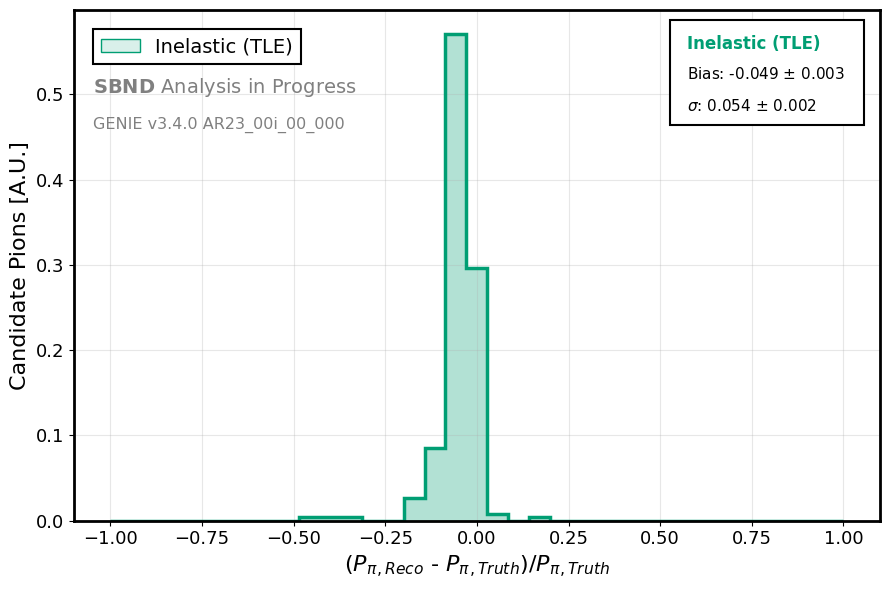

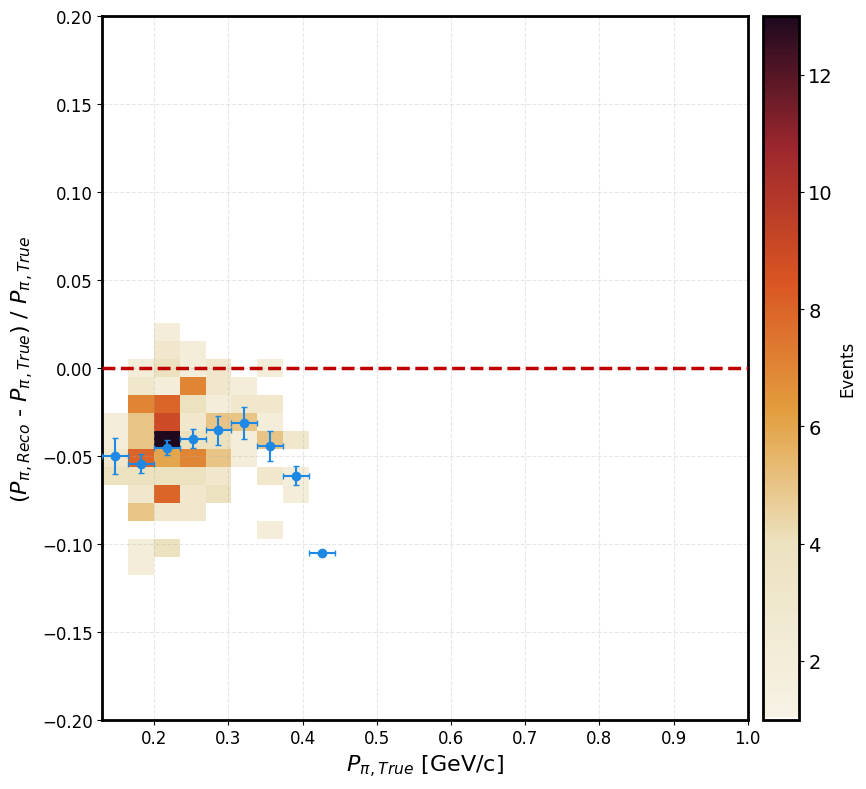

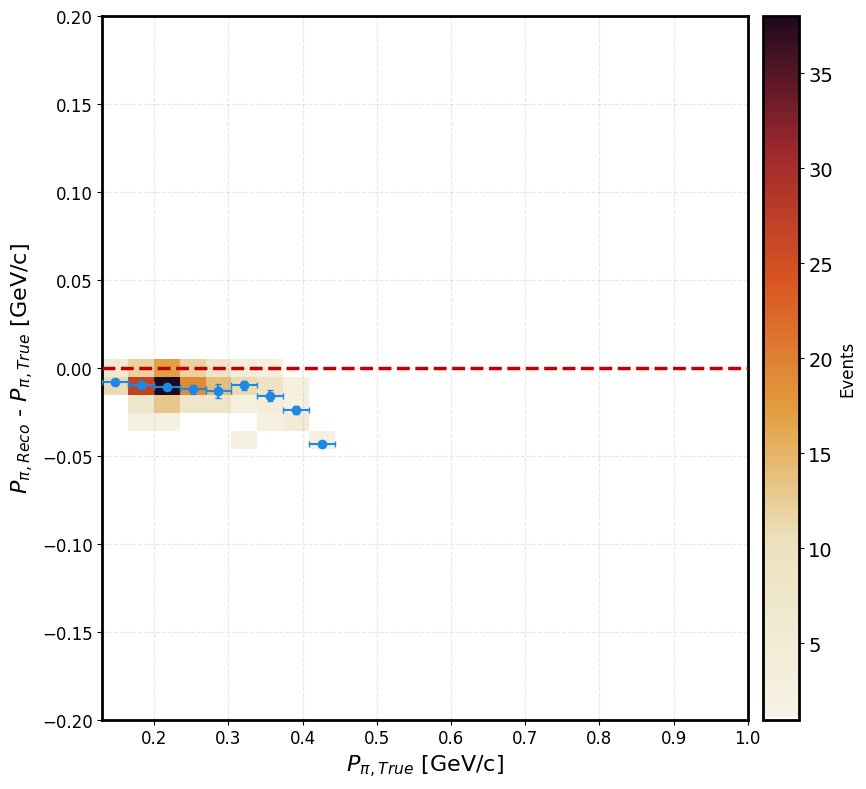

103766
20747


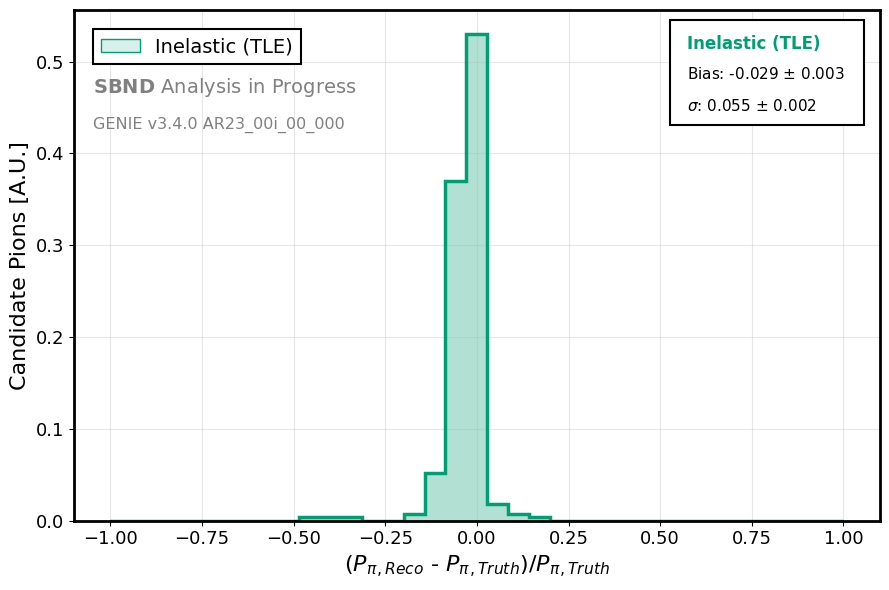

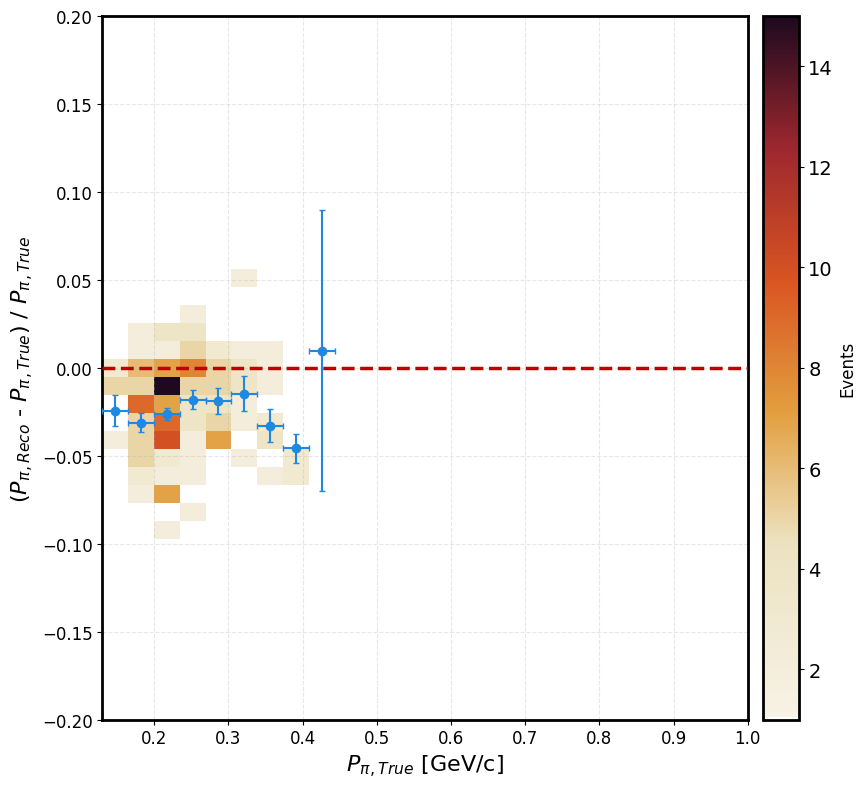

KeyboardInterrupt: 

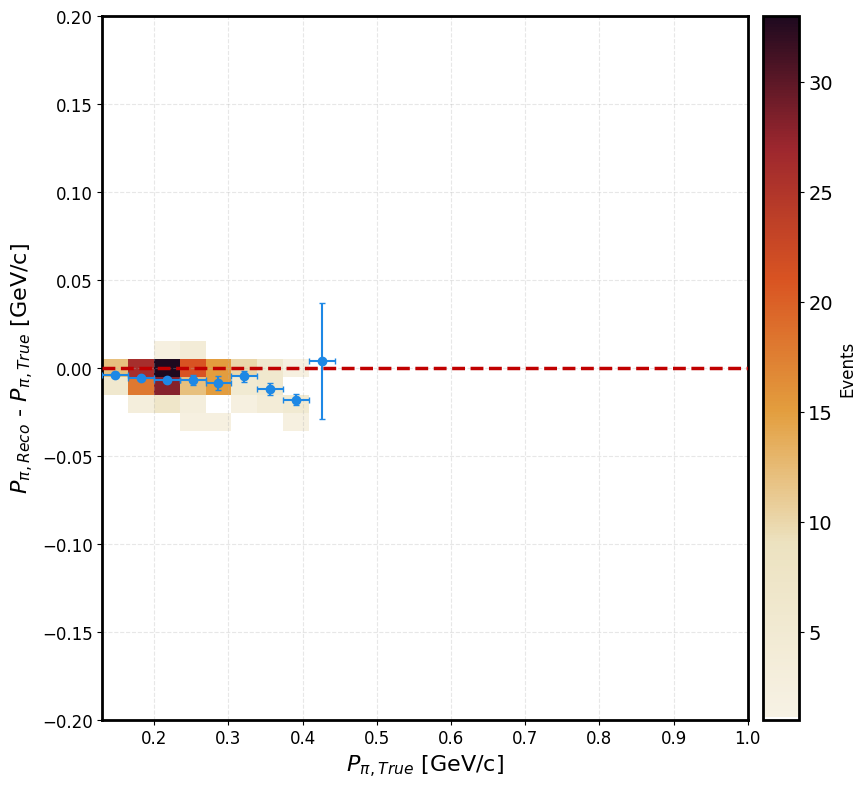

In [21]:
# ==========================================
# 2. EXECUTION LOOP
# ==========================================
prefix = "range" if use_range_momentum else "true"
base_out = output_dir / f"{prefix}_{filename}"
base_out.mkdir(parents=True, exist_ok=True)

presets = df["method"].unique()
config = PlotConfig()
if "13" in filename:
    # Instantiate with Muon parameters:
    config = PlotConfig(
        title=r"$P_{\mu}$",
        ylabel="Candidate Muons [A.U.]",
        bins=np.linspace(0.1, 1, 26),
    )

for hit_label, hit_mask in build_hit_bin_masks(
    df, use_num_hits, hit_bins, hits_to_plot
):
    hit_path = base_out / hit_label
    hit_path.mkdir(parents=True, exist_ok=True)

    for preset in presets:
        preset_mask = (
            (df["method"] == preset)
            & hit_mask
            & plot_inter_mask(df, plot_inter)
        )
        if preset_mask.sum() == 0:
            print(f"Skipping {preset} under {hit_label}: 0 matching events")
            continue
        
        print(len(df))
        print(len(df[df["method"] == preset]))
        preset_path = hit_path / preset
        preset_path.mkdir(parents=True, exist_ok=True)

        # 1. 1D Residual
        fig = plot_1d_res(
            df,
            config,
            use_percent_bias=True,
            extra_mask=preset_mask.values,
            plot_inter=plot_inter
        )
        fig.savefig(preset_path / "Res.pdf")
        plt.close(fig)

        # 2. 2D Bias vs P_True (Fractional)
        plot_bias_h2_python(
            config=config,
            df=df,
            x_axis_column=getattr(config, "truth_column", "p_true"),
            x_axis_title=f"{config.title}$_{{,True}}$ {getattr(config, 'unit', 'GeV')}",
            extra_mask=preset_mask.values,
            use_percent_bias=True,
            use_range_momentum=use_range_momentum,
            output_dir=preset_path,
        )

        # 3. 2D Bias vs P_True (Absolute)
        plot_bias_h2_python(
            config=config,
            df=df,
            x_axis_column=getattr(config, "truth_column", "p_true"),
            x_axis_title=f"{config.title}$_{{,True}}$ {getattr(config, 'unit', 'GeV')}",
            extra_mask=preset_mask.values,
            use_percent_bias=False,
            use_range_momentum=use_range_momentum,
            output_dir=preset_path,
        )

        # 4. 2D Bias vs Chi2_pi (Fractional)
        if "chi2_pi" in df.columns:
            plot_bias_h2_python(
                config=config,
                df=df,
                x_axis_column="chi2_pi",
                x_axis_title=r"$\chi^{2}_{\pi}$",
                extra_mask=preset_mask.values,
                use_percent_bias=True,
                use_range_momentum=use_range_momentum,
                output_dir=preset_path,
            )

print(f"Done. Plots written under: {base_out}")

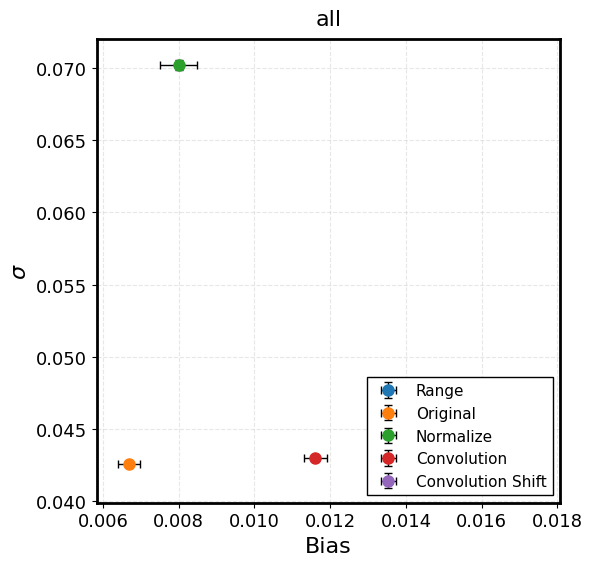

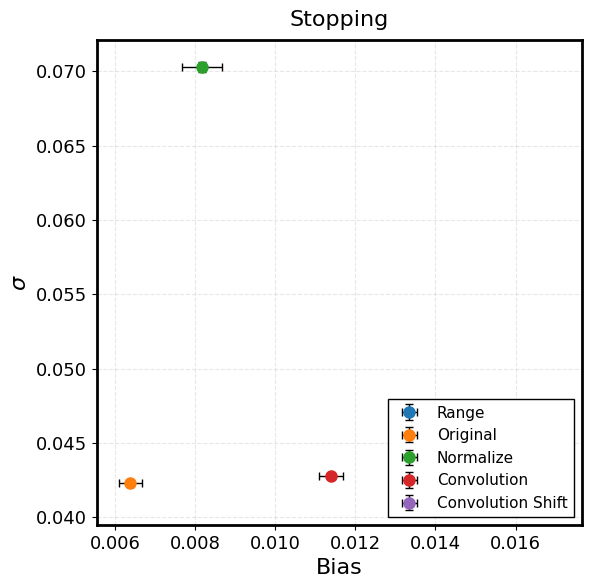

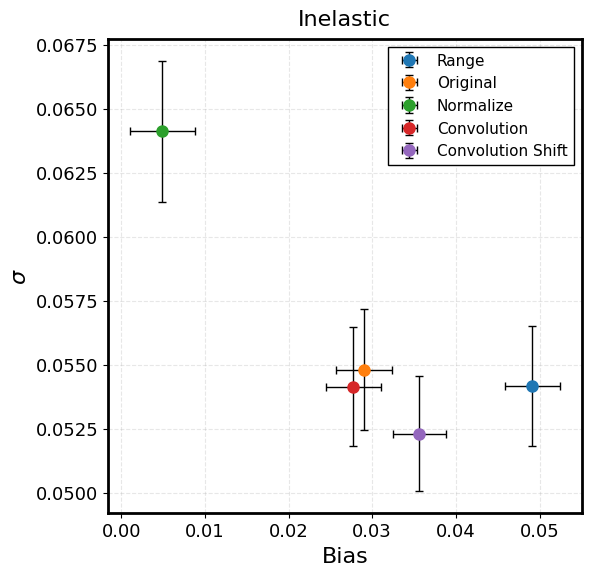

In [15]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Name Mapping
PRESET_LABELS = {
    "range": "Range",
    "original": "Original",
    "normalize_clean_dEdx_include_small": "Normalize",
    "convolution_normalize_clean_dEdx_include_small_og": "Convolution",
    "convolution_normalize_clean_dEdx_include_small_shifted": "Convolution Shift",
}

p_type_vec = ["all", "Stopping", "Inelastic"]
if "13" in filename:
    p_type_vec = ["all"]
    
presets = list(df["method"].unique())
preset_colors = {preset: cm.tab10(i % 10) for i, preset in enumerate(presets)}


# --- Metric Calculation ---
def get_bias_res(series):
    # Ignore points where (Preco - Ptrue) / Ptrue > 1 or < -1
    vals = series[(series > -1.0) & (series < 1.0)]
    n = len(vals)
    if n == 0:
        return pd.Series(
            [0.0, 0.0, 0.0, 0.0],
            index=["bias", "bias_err", "res", "res_err"],
        )

    bias = abs(vals.mean())
    res = vals.std(ddof=1)
    bias_err = res / np.sqrt(n)
    res_err = res / np.sqrt(2 * n)
    return pd.Series(
        [bias, bias_err, res, res_err],
        index=["bias", "bias_err", "res", "res_err"],
    )


# --- Aggregate Data per Subsample ---
stats = []
for p_type in p_type_vec:
    if p_type == "all":
        sub_df = df.copy()
    else:
        sub_df = df[df["p_type"] == f"{p_type.lower()} pion"]

    res_df = (
        sub_df.groupby("method")["residual"]
        .apply(get_bias_res)
        .unstack()
        .reset_index()
    )
    res_df["p_type"] = p_type
    stats.append(res_df)

stats_df = pd.concat(stats, ignore_index=True)

# --- Plot Generation ---
for p_type in p_type_vec:
    # 6x6 figure with equal aspect box guarantees a square plot
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_box_aspect(1)

    p_data = stats_df[stats_df["p_type"] == p_type]

    for preset in presets:
        row = p_data[p_data["method"] == preset]
        if row.empty:
            continue

        label_name = PRESET_LABELS.get(preset, preset)

        # Draw point with error bar together in a single step
        ax.errorbar(
            row["bias"].values[0],
            row["res"].values[0],
            xerr=row["bias_err"].values[0],
            yerr=row["res_err"].values[0],
            fmt="o",
            color=preset_colors[preset],
            ecolor="black",
            elinewidth=1,
            capsize=3,
            markersize=8,
            zorder=2,
            label=label_name,
        )

    # Styling and Formatting
    ax.set_title(p_type, fontsize=16, pad=10)
    ax.set_xlabel("Bias", fontsize=16)
    ax.set_ylabel(r"$\sigma$", fontsize=16)  # Renamed to \sigma
    ax.tick_params(labelsize=13)
    ax.grid(True, alpha=0.3, linestyle="--")

    # Legend Position: 'upper right' for Inelastic, 'lower right' for others
    leg_loc = "upper right" if p_type == "Inelastic" else "lower right"
    ax.legend(
        loc=leg_loc,
        fontsize=11,
        framealpha=1.0,
        edgecolor="black",
        fancybox=False,
    )

    fig.tight_layout()
    fig.savefig(f"{output_dir}/{p_type}_ResBiasGraph.pdf")